In [87]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.table import Table

import pandas as pd
import pyStarlet_master_2D1D as pys


from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from matplotlib.colors import LogNorm
from scipy.ndimage import gaussian_filter1d

import torch

# DECLARE CONSTANTS

EVT_FILE = 'acisi_merged.fits'
XMIN = 4085
XMAX = 4120
YMIN = 4080
YMAX = 4120

EMIN = 2000
EMAX = 5500

BINX = 32
BINY = 32
BINE = 50

VERBOSE = False

NUM_LVL = 2
LVL_START = 1

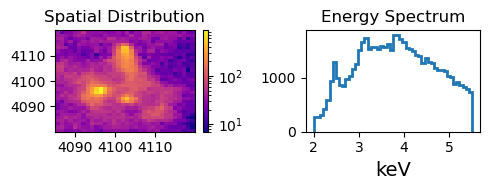

<Figure size 400x400 with 0 Axes>

<Figure size 400x400 with 0 Axes>

In [88]:

hdu = fits.open(EVT_FILE)
evt_data = hdu[1].data

cols = ['energy', 'x', 'y', 'ccd_id']
df = Table([evt_data[c] for c in cols], names=cols).to_pandas()

subset = df[(df['x'] > XMIN) & (df['x'] < XMAX) & \
            (df['y'] > YMIN) & (df['y'] < YMAX) & \
            (df['energy'] > EMIN) & (df['energy'] < EMAX)]

fig = plt.figure(figsize=(5, 2)) 
ax1 = fig.add_subplot(1, 2, 1)
h2d = ax1.hist2d(subset['x'], subset['y'], bins=(BINX, BINY), 
                 cmap='plasma', norm=LogNorm())
ax1.set_title('Spatial Distribution')
fig.colorbar(h2d[3], ax=ax1)

ax2 = fig.add_subplot(1, 2, 2)
ax2.hist(subset['energy']/1.e3, bins=BINE, histtype='step', lw=2)
ax2.set_xlabel('keV', size=14)
ax2.set_title('Energy Spectrum')

plt.tight_layout()
plt.show()
plt.figure(2, figsize=(4,4))

In [89]:
spectral_cube, _ = np.histogramdd(subset[['energy', 'x', 'y']].values, bins=(BINE, BINX, BINY))
spectral_cube_tensor = torch.tensor(spectral_cube, dtype=torch.float32)
starlet_cube = pys.Starlet_Forward3D(spectral_cube,J=4)[:,:,:,LVL_START:LVL_START+NUM_LVL]
print(starlet_cube.shape)
raw_energy_level = spectral_cube[..., np.newaxis]
combined_cube = torch.from_numpy(np.concatenate([raw_energy_level, starlet_cube], axis=-1)).permute(0, 3, 1, 2)
print(combined_cube.shape)

# add starlet transform to subset
_, edges = np.histogramdd(subset[['energy', 'x', 'y']].values, bins=(BINE, BINX, BINY))

dims = ['energy', 'x', 'y']
indices = []
for i, col in enumerate(dims):
    # Find bin index (subtract 1 for 0-indexing)
    idx = np.digitize(subset[col].values, edges[i]) - 1
    # Clip to stay within cube boundaries
    idx = np.clip(idx, 0, starlet_cube.shape[i] - 1)
    indices.append(idx)
e_idx, x_idx, y_idx = indices

e_lvls = ['energy']

for lvl in range(NUM_LVL):
    subset[f'starlet_{lvl}'] = starlet_cube[e_idx, x_idx, y_idx, lvl]
    e_lvls.append(f'starlet_{lvl}')

(50, 32, 32, 2)
torch.Size([50, 3, 32, 32])


/tmp/ipykernel_25800/2185966632.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset[f'starlet_{lvl}'] = starlet_cube[e_idx, x_idx, y_idx, lvl]
/tmp/ipykernel_25800/2185966632.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset[f'starlet_{lvl}'] = starlet_cube[e_idx, x_idx, y_idx, lvl]


Background table size: 37159
Source table size: 22616


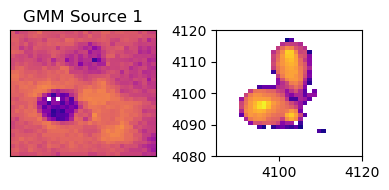

In [124]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
scaled_df = std_scaler.fit_transform(subset[['x', 'y', 'energy', 'starlet_0', 'starlet_1']])

NCOMP = 2
gmm = GaussianMixture(
    n_components=NCOMP,
    covariance_type='full',   # most flexible; try 'diag' if you want faster
    random_state=0
)

gmm.fit(scaled_df)
probs = gmm.predict_proba(scaled_df)
labels = gmm.predict(scaled_df) 

table_bg = subset[labels == 0][['energy', 'starlet_0', 'starlet_1', 'x', 'y']].copy()
table_source = subset[labels == 1][['energy', 'starlet_0', 'starlet_1', 'x', 'y']].copy()

table_bg['weight'] = probs[labels == 0, 0]
table_source['weight'] = probs[labels == 1, 1]

print(f"Background table size: {len(table_bg)}")
print(f"Source table size: {len(table_source)}")

VMIN = 0.5
VMAX = 1e3

fig = plt.figure(figsize=(2 * NCOMP, 2))

ax = plt.subplot(100 + 10 * NCOMP + 1)

h = ax.hist2d(
    table_bg['x'],
    table_bg['y'],
    bins=(BINX, BINY),
    range=[[XMIN, XMAX], [YMIN, YMAX]],
    weights=table_bg['weight'],
    cmap='plasma',
    norm=LogNorm(vmin=VMIN, vmax=VMAX)
)

ax.set_title(f'GMM Source {i}')
ax.set_xlim(XMIN, XMAX)
ax.set_ylim(YMIN, YMAX)
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)

ax = plt.subplot(100 + 10 * NCOMP + 2)

h = ax.hist2d(
    table_source['x'],
    table_source['y'],
    bins=(BINX, BINY),
    range=[[XMIN, XMAX], [YMIN, YMAX]],
    weights=table_source['weight'],
    cmap='plasma',
    norm=LogNorm(vmin=VMIN, vmax=VMAX)
)

plt.tight_layout()

In [136]:
scaled_star_df = std_scaler.fit_transform(table_source[['x', 'y', 'energy']])

nb_source = 3
gmm = GaussianMixture(
    n_components=nb_source,
    covariance_type='full',   # most flexible; try 'diag' if you want faster
    random_state=0
)

gmm.fit(scaled_star_df)
probs2 = gmm.predict_proba(scaled_star_df)
labels2 = gmm.predict(scaled_star_df)

sources = []
for i in range(nb_source):
    sources.append(table_source[labels2 == i][['energy', 'x', 'y']].copy())
    sources[-1]['weight'] = probs2[labels2 == i, i]


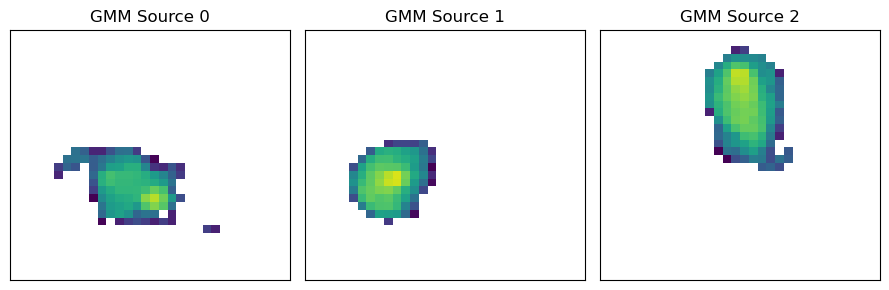

In [137]:
fig = plt.figure(figsize=(3 * nb_source, 3))

for i in range(nb_source):
    ax = plt.subplot(100 + 10 * nb_source + i + 1)

    h = ax.hist2d(
        sources[i]['x'],
        sources[i]['y'],
        bins=(BINX, BINY),
        range=[[XMIN, XMAX], [YMIN, YMAX]],
        weights=sources[i]['weight'],
        cmap='viridis',
        norm=LogNorm(vmin=VMIN, vmax=VMAX)
    )

    ax.set_title(f'GMM Source {i}')
    ax.set_xlim(XMIN, XMAX)
    ax.set_ylim(YMIN, YMAX)
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)

plt.tight_layout()

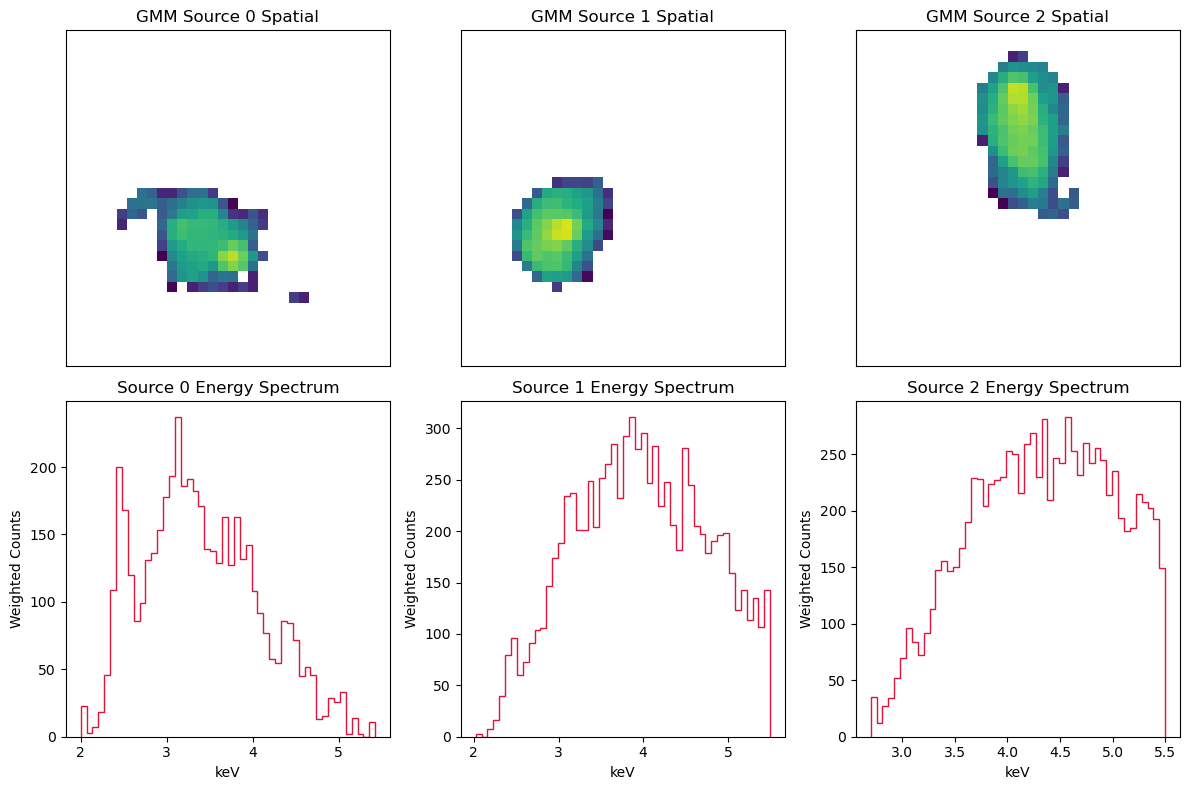

In [144]:
# Create a figure with 2 rows and nb_source columns
fig, axes = plt.subplots(2, nb_source, figsize=(4 * nb_source, 8))

# If nb_source is 1, axes is not a 2D array, so we ensure it is
if nb_source == 1:
    axes = np.atleast_2d(axes).T

for i in range(nb_source):
    # --- ROW 1: SPATIAL (TOP) ---
    ax_top = axes[0, i]
    h = ax_top.hist2d(
        sources[i]['x'],
        sources[i]['y'],
        bins=(BINX, BINY),
        range=[[XMIN, XMAX], [YMIN, YMAX]],
        weights=sources[i]['weight'],
        cmap='viridis',
        norm=LogNorm(vmin=VMIN, vmax=VMAX)
    )
    ax_top.set_title(f'GMM Source {i} Spatial')
    ax_top.xaxis.set_visible(False)
    ax_top.yaxis.set_visible(False)

    # --- ROW 2: SPECTRAL (BOTTOM) ---
    ax_bottom = axes[1, i]
    ax_bottom.hist(
        sources[i]['energy']/1e3,
        bins=BINE,
        histtype='step',
        color='crimson'
    )
    ax_bottom.set_title(f'Source {i} Energy Spectrum')
    ax_bottom.set_xlabel('keV')
    ax_bottom.set_ylabel('Weighted Counts')

plt.tight_layout()
plt.show()